# Climate Change Slope Analysis: Spatial Regression & Multilinear Modeling

This notebook consolidates spatial regression and slope comparison analyses to understand how climate change trends vary across geographic locations.

## Overview
- **Part 1**: Load data with climatological features (automatically added by main.py) and perform multilinear regression modeling local climate change slope based on geographical and climatological factors
- **Part 2**: Generate predictions using regression coefficients and compare predicted vs actual slopes
- **Part 3**: Visualize results through scatter plots, maps, and statistical summaries

**Note:** Make sure to run `main.py` first to generate station_data.csv with all climatological features.

In [6]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os
from pathlib import Path

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## Configuration

Set the file paths for input data and output results:

In [ ]:
# Configuration: File Paths
ORIGINAL_DATA_CSV = '../output/station_data.csv'          # Input data with all features
REGRESSION_RESULTS_CSV = '../output/spatial_analysis_simple.csv'  # Regression coefficients
OUTPUT_COMPARISON_CSV = './notebook_outputs/multilinear/slope_comparison_simple.csv'   # Comparison results
OUTPUT_DIR = './notebook_outputs/multilinear'

# Ensure output directory exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Input file: {ORIGINAL_DATA_CSV}")
print(f"Output directory: {OUTPUT_DIR}")

Input file: ../output/station_data.csv
Output directory: ../output/multilinear


## Part 1: Data Loading & Exploration

Load the station data and explore its structure:

In [9]:
# Load the data
print(f"Loading data from '{ORIGINAL_DATA_CSV}'...")
try:
    df = pd.read_csv(ORIGINAL_DATA_CSV)
    print(f"Successfully loaded {len(df)} stations")
except FileNotFoundError as e:
    print(f"✗ Error: {e}")
    raise

# Display basic information
print("\n--- Data Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- First few rows ---")
df.head()

Loading data from '../output/station_data.csv'...
Successfully loaded 21 stations

--- Data Shape ---
Rows: 21, Columns: 13

--- First few rows ---


,StationID,Latitude,Longitude,Elevation,StationName,slope,intercept,r_squared,regression_plot,residual_plot,timeseries_plot,climo_temp,climo_humidity
0,USC00083207,27.4419,-80.3508,7.6,FT_PIERCE,1.272192,-0.317535,0.588628,plots/USC00083207/regression.png,plots/USC00083207/residual.png,plots/USC00083207/timeseries.png,23.127167,74.000000
1,CHM00057713,27.7000,106.8830,845.0,ZUNYI,1.083615,-0.147224,0.421044,plots/CHM00057713/regression.png,plots/CHM00057713/residual.png,plots/CHM00057713/timeseries.png,16.136410,76.783333
2,ASN00066037,-33.9465,151.1731,6.0,SYDNEY_AIRPORT_AMO,1.590236,-0.374604,0.738315,plots/ASN00066037/regression.png,plots/ASN00066037/residual.png,plots/ASN00066037/timeseries.png,18.523897,62.341667
3,USW00013991,39.1342,-93.2225,240.8,MARSHALL,0.410177,-0.101153,0.044680,plots/USW00013991/regression.png,plots/USW00013991/residual.png,plots/USW00013991/timeseries.png,12.560768,69.458333
4,USC00103143,46.0931,-115.5356,475.5,FENN_RS,0.697019,-0.107765,0.197517,plots/USC00103143/regression.png,plots/USC00103143/residual.png,plots/USC00103143/timeseries.png,10.272943,63.508333


In [10]:
# Display data info and statistics
print("\n--- Data Types ---")
print(df.dtypes)

missing_data = df.isnull().sum()
if missing_data.sum() > 0:
    print("\n--- Missing Values ---")
    print(missing_data[missing_data > 0])

print("\n--- Column Names ---")
print(df.columns.tolist())


--- Data Types ---
StationID              str
Latitude           float64
Longitude          float64
Elevation          float64
StationName            str
slope              float64
intercept          float64
r_squared          float64
regression_plot        str
residual_plot          str
timeseries_plot        str
climo_temp         float64
climo_humidity     float64
dtype: object

--- Missing Values ---
climo_humidity    2
dtype: int64

--- Column Names ---
['StationID', 'Latitude', 'Longitude', 'Elevation', 'StationName', 'slope', 'intercept', 'r_squared', 'regression_plot', 'residual_plot', 'timeseries_plot', 'climo_temp', 'climo_humidity']


## Part 2: Spatial Regression Analysis

This section performs multilinear regression to model climate change slope based on:
- **Dependent Variable**: `slope` (local climate change trend)
- **Independent Variables**: `climo_temp` (climatological temperature), `climo_humidity` (climatological humidity)

The regression will estimate coefficients showing how each factor influences the local warming trend.

In [11]:
# define target and features
target_col = 'slope'
feature_cols = ['climo_temp', 'climo_humidity']

# data cleaning
print("--- Data Cleaning ---")
missing_cols = [c for c in feature_cols + [target_col] if c not in df.columns]
if missing_cols:
    print(f"Error: Missing columns: {missing_cols}")
else:
    print(f"All required columns present: {feature_cols + [target_col]}")

# Drop rows with missing values
initial_count = len(df)
df_clean = df.dropna(subset=[target_col] + feature_cols)
cleaned_count = len(df_clean)

if cleaned_count < initial_count:
    print(f"Dropped {initial_count - cleaned_count} rows due to missing data")
    print(f"  Remaining records: {cleaned_count}")
else:
    print(f"No missing values in regression variables")

if cleaned_count == 0:
    print("Error: No data remaining after cleaning")
    raise ValueError("Empty dataset after cleaning")

--- Data Cleaning ---
All required columns present: ['climo_temp', 'climo_humidity', 'slope']
Dropped 2 rows due to missing data
  Remaining records: 19


In [12]:
# Prepare data for regression
X = df_clean[feature_cols].copy()
y = df_clean[target_col].copy()

# Add constant (intercept term)
X = sm.add_constant(X)

print(f"\n--- Regression Setup ---")
print(f"Observations: {len(y)}")
print(f"Features: {feature_cols}")
print(f"\nDependent Variable ({target_col}) Statistics:")
print(f"  Mean: {y.mean():.6f}")
print(f"  Std: {y.std():.6f}")
print(f"  Min: {y.min():.6f}")
print(f"  Max: {y.max():.6f}")


--- Regression Setup ---
Observations: 19
Features: ['climo_temp', 'climo_humidity']

Dependent Variable (slope) Statistics:
  Mean: 1.536063
  Std: 0.893260
  Min: 0.410177
  Max: 3.350626


In [13]:
# Fit OLS Regression Model
print("\n--- Fitting OLS Regression Model ---")
model = sm.OLS(y, X).fit()

print("Model fitted successfully")

# Step 5: Extract and save results
print("\n" + model.summary().as_text())


--- Fitting OLS Regression Model ---
Model fitted successfully

                            OLS Regression Results                            
Dep. Variable:                  slope   R-squared:                       0.431
Model:                            OLS   Adj. R-squared:                  0.359
Method:                 Least Squares   F-statistic:                     6.049
Date:                Thu, 26 Feb 2026   Prob (F-statistic):             0.0111
Time:                        12:31:06   Log-Likelihood:                -18.952
No. Observations:                  19   AIC:                             43.90
Df Residuals:                      16   BIC:                             46.74
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [14]:
# Create results dataframe
results_data = []

# Extract model statistics
r_squared = model.rsquared
adj_r_squared = model.rsquared_adj
f_pvalue = model.f_pvalue

# Build results for each predictor
for term in model.params.index:
    row = {
        'Factor': term,
        'Coefficient (Slope)': model.params[term],
        'Std Error': model.bse[term],
        'P-Value': model.pvalues[term],
        'T-Value': model.tvalues[term],
        'Conf_Int_Low (2.5%)': model.conf_int().loc[term][0],
        'Conf_Int_High (97.5%)': model.conf_int().loc[term][1],
        'Model_R_Squared': r_squared,
        'Model_Adj_R_Squared': adj_r_squared,
        'Model_Prob(F-Stat)': f_pvalue,
        'Observations': model.nobs
    }
    results_data.append(row)

# Create DataFrame
results_df = pd.DataFrame(results_data)

# Reorder columns for readability
cols = ['Factor', 'Coefficient (Slope)', 'P-Value', 'Model_R_Squared'] + \
       [c for c in results_df.columns if c not in ['Factor', 'Coefficient (Slope)', 'P-Value', 'Model_R_Squared']]
results_df = results_df[cols]

# Display results
print("\n--- Regression Coefficients ---")
print(results_df.to_string())


--- Regression Coefficients ---
           Factor  Coefficient (Slope)   P-Value  Model_R_Squared  Std Error   T-Value  Conf_Int_Low (2.5%)  Conf_Int_High (97.5%)  Model_Adj_R_Squared  Model_Prob(F-Stat)  Observations
0           const             0.176927  0.939343         0.430547   2.288828  0.077300            -4.675172               5.029027             0.359366            0.011058          19.0
1      climo_temp            -0.068346  0.012159         0.430547   0.024181 -2.826463            -0.119606              -0.017085             0.359366            0.011058          19.0
2  climo_humidity             0.027998  0.373054         0.430547   0.030552  0.916419            -0.036768               0.092764             0.359366            0.011058          19.0


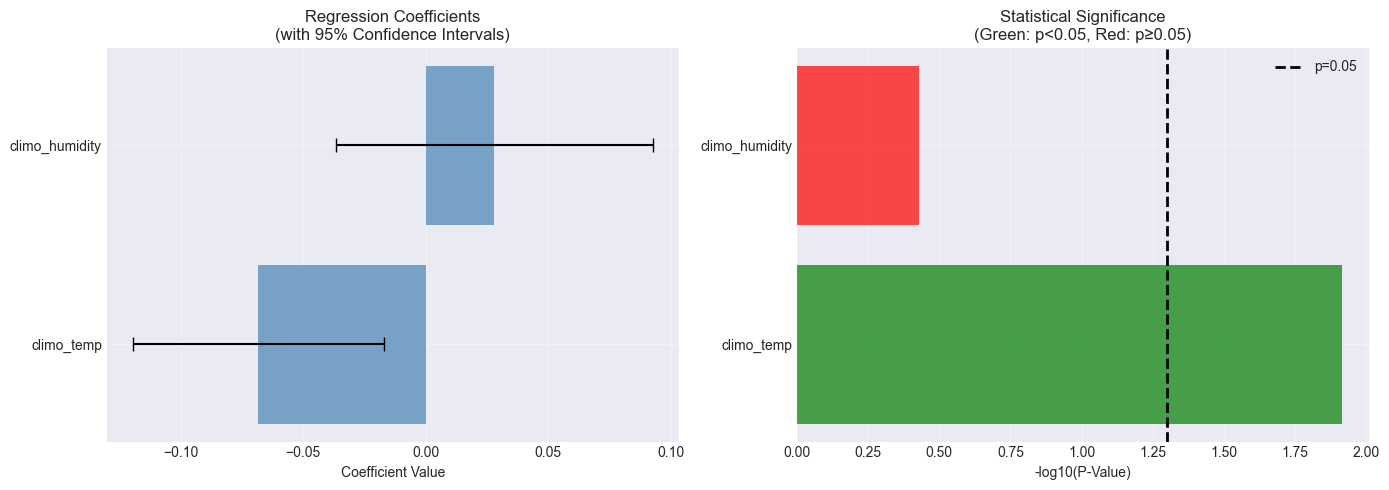

In [15]:
# Visualize regression summary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Coefficients with confidence intervals
coeffs_df = results_df[results_df['Factor'] != 'const'].copy()
coeffs_df = coeffs_df.sort_values('Coefficient (Slope)')

y_pos = np.arange(len(coeffs_df))
axes[0].barh(y_pos, coeffs_df['Coefficient (Slope)'], 
             xerr=[coeffs_df['Coefficient (Slope)'] - coeffs_df['Conf_Int_Low (2.5%)'],
                   coeffs_df['Conf_Int_High (97.5%)'] - coeffs_df['Coefficient (Slope)']],
             capsize=5, color='steelblue', alpha=0.7)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(coeffs_df['Factor'])
axes[0].set_xlabel('Coefficient Value')
axes[0].set_title('Regression Coefficients\n(with 95% Confidence Intervals)')
axes[0].grid(True, alpha=0.3)

# Plot 2: P-values
pval_colors = ['green' if p < 0.05 else 'red' for p in coeffs_df['P-Value']]
axes[1].barh(y_pos, -np.log10(coeffs_df['P-Value']), color=pval_colors, alpha=0.7)
axes[1].axvline(x=-np.log10(0.05), color='black', linestyle='--', label='p=0.05', linewidth=2)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(coeffs_df['Factor'])
axes[1].set_xlabel('-log10(P-Value)')
axes[1].set_title('Statistical Significance\n(Green: p<0.05, Red: p≥0.05)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 3: Slope Prediction & Comparison

Now we use the regression coefficients to predict the climate change slope at each station and compare predicted vs actual values.

In [16]:
# Create a working copy of the original data
df_comparison = df.copy()

# Convert coefficients to dictionary
coeffs = pd.Series(
    results_df['Coefficient (Slope)'].values,
    index=results_df['Factor']
).to_dict()

print("--- Regression Coefficients ---")
for factor, coeff in coeffs.items():
    print(f"  {factor}: {coeff:.6f}")

# Make predictions
print("\n--- Making Predictions ---")

# Start with intercept
intercept = coeffs.get('const', 0.0)
df_comparison['Predicted_Slope'] = intercept

# Add contributions from each feature
predictors = ['climo_temp', 'climo_humidity']

for feature in predictors:
    if feature in coeffs and feature in df_comparison.columns:
        contribution = df_comparison[feature] * coeffs[feature]
        df_comparison['Predicted_Slope'] += contribution
        print(f"✓ Added {feature} contribution")
    elif feature not in df_comparison.columns:
        print(f"⚠ Warning: {feature} not found in data")

# Calculate actual slope and residuals
df_comparison['Actual_Slope'] = df_comparison['slope']
df_comparison['Residual'] = df_comparison['Actual_Slope'] - df_comparison['Predicted_Slope']

print(f"\n✓ Predictions generated for {len(df_comparison)} stations")

--- Regression Coefficients ---
  const: 0.176927
  climo_temp: -0.068346
  climo_humidity: 0.027998

--- Making Predictions ---
✓ Added climo_temp contribution
✓ Added climo_humidity contribution

✓ Predictions generated for 21 stations


In [17]:
# Save comparison data to CSV
output_cols = [
    'StationID', 'StationName', 'Latitude', 'Longitude', 'Elevation',
    'Actual_Slope', 'Predicted_Slope', 'Residual'
]
# Only keep columns that exist
final_cols = [c for c in output_cols if c in df_comparison.columns]

# Display statistics
print("\n--- Prediction Statistics ---")
print(f"\nActual Slope:")
print(f"  Mean: {df_comparison['Actual_Slope'].mean():.6f}")
print(f"  Std Dev: {df_comparison['Actual_Slope'].std():.6f}")
print(f"  Range: [{df_comparison['Actual_Slope'].min():.6f}, {df_comparison['Actual_Slope'].max():.6f}]")

print(f"\nPredicted Slope:")
print(f"  Mean: {df_comparison['Predicted_Slope'].mean():.6f}")
print(f"  Std Dev: {df_comparison['Predicted_Slope'].std():.6f}")
print(f"  Range: [{df_comparison['Predicted_Slope'].min():.6f}, {df_comparison['Predicted_Slope'].max():.6f}]")

print(f"\nResiduals (Actual - Predicted):")
print(f"  Mean: {df_comparison['Residual'].mean():.6f}")
print(f"  Std Dev: {df_comparison['Residual'].std():.6f}")
print(f"  Range: [{df_comparison['Residual'].min():.6f}, {df_comparison['Residual'].max():.6f}]")

# Calculate model fit metrics (remove NaN values first)
from sklearn.metrics import mean_squared_error, r2_score

# Filter out rows with NaN predictions
df_valid = df_comparison.dropna(subset=['Actual_Slope', 'Predicted_Slope'])

if len(df_valid) > 0:
    mse = mean_squared_error(df_valid['Actual_Slope'], df_valid['Predicted_Slope'])
    rmse = np.sqrt(mse)
    r2 = r2_score(df_valid['Actual_Slope'], df_valid['Predicted_Slope'])
    
    print(f"\nModel Performance (n={len(df_valid)} stations with valid predictions):")
    print(f"  Mean Squared Error: {mse:.6f}")
    print(f"  Root Mean Squared Error: {rmse:.6f}")
    print(f"  R² Score: {r2:.4f}")
    
    if len(df_valid) < len(df_comparison):
        print(f"\nNote: {len(df_comparison) - len(df_valid)} stations excluded due to missing data")
else:
    print("Error: No valid predictions available for metrics calculation")


--- Prediction Statistics ---

Actual Slope:
  Mean: 1.531993
  Std Dev: 0.849298
  Range: [0.410177, 3.350626]

Predicted Slope:
  Mean: 1.536063
  Std Dev: 0.586122
  Range: [0.656340, 2.977563]

Residuals (Actual - Predicted):
  Mean: 0.000000
  Std Dev: 0.674073
  Range: [-0.852970, 1.526325]

Model Performance (n=19 stations with valid predictions):
  Mean Squared Error: 0.430460
  Root Mean Squared Error: 0.656094
  R² Score: 0.4305

Note: 2 stations excluded due to missing data


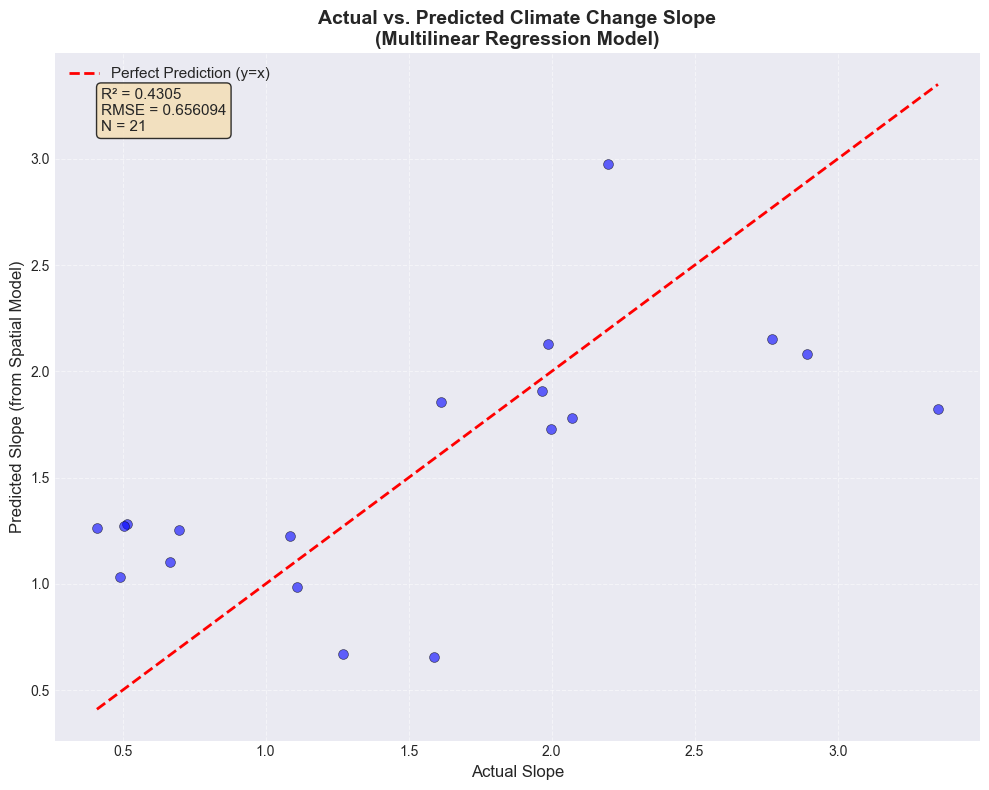

In [18]:
# Visualize: Actual vs Predicted Slopes
plt.figure(figsize=(10, 8))

plt.scatter(df_comparison['Actual_Slope'], df_comparison['Predicted_Slope'], 
            alpha=0.6, color='blue', s=50, edgecolors='black', linewidth=0.5)

# Add perfect prediction line (y=x)
min_val = min(df_comparison['Actual_Slope'].min(), df_comparison['Predicted_Slope'].min())
max_val = max(df_comparison['Actual_Slope'].max(), df_comparison['Predicted_Slope'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', 
         linewidth=2, label='Perfect Prediction (y=x)')

plt.title('Actual vs. Predicted Climate Change Slope\n(Multilinear Regression Model)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Slope', fontsize=12)
plt.ylabel('Predicted Slope (from Spatial Model)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Add stats text box
textstr = f'R² = {r2:.4f}\nRMSE = {rmse:.6f}\nN = {len(df_comparison)}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

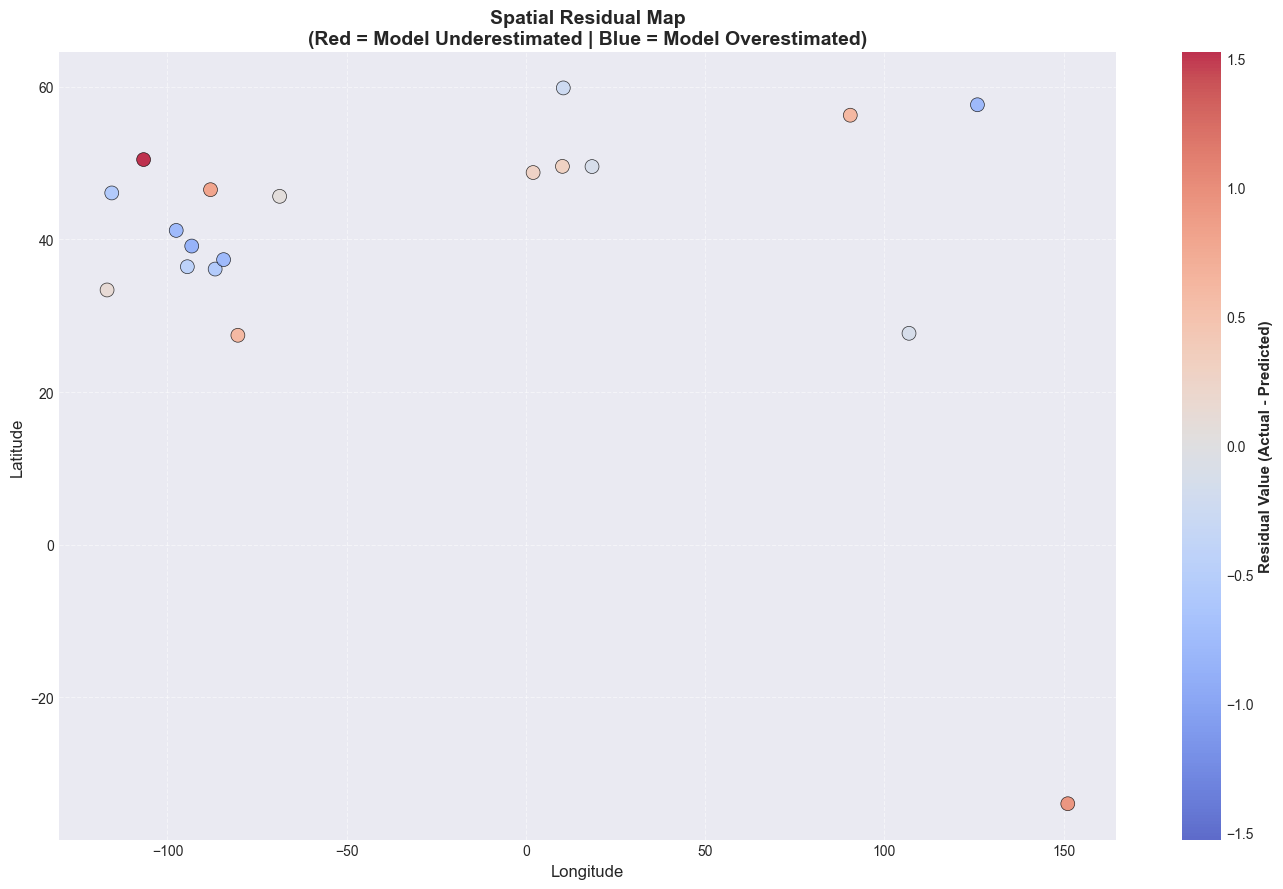

In [19]:
# Visualize: Spatial Residual Map
plt.figure(figsize=(14, 9))

# Scatter plot with residuals as colors
# Blue = Model Overestimated (negative residual)
# Red = Model Underestimated (positive residual)
sc = plt.scatter(
    df_comparison['Longitude'],
    df_comparison['Latitude'],
    c=df_comparison['Residual'],
    cmap='coolwarm',
    s=100,
    alpha=0.8,
    edgecolors='black',
    linewidth=0.5,
    vmin=-np.abs(df_comparison['Residual']).max(),
    vmax=np.abs(df_comparison['Residual']).max()
)

# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Residual Value (Actual - Predicted)', fontsize=11, fontweight='bold')

plt.title('Spatial Residual Map\n(Red = Model Underestimated | Blue = Model Overestimated)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Part 4: Detailed Diagnostic Visualizations

Explore model residuals and feature relationships in more detail:

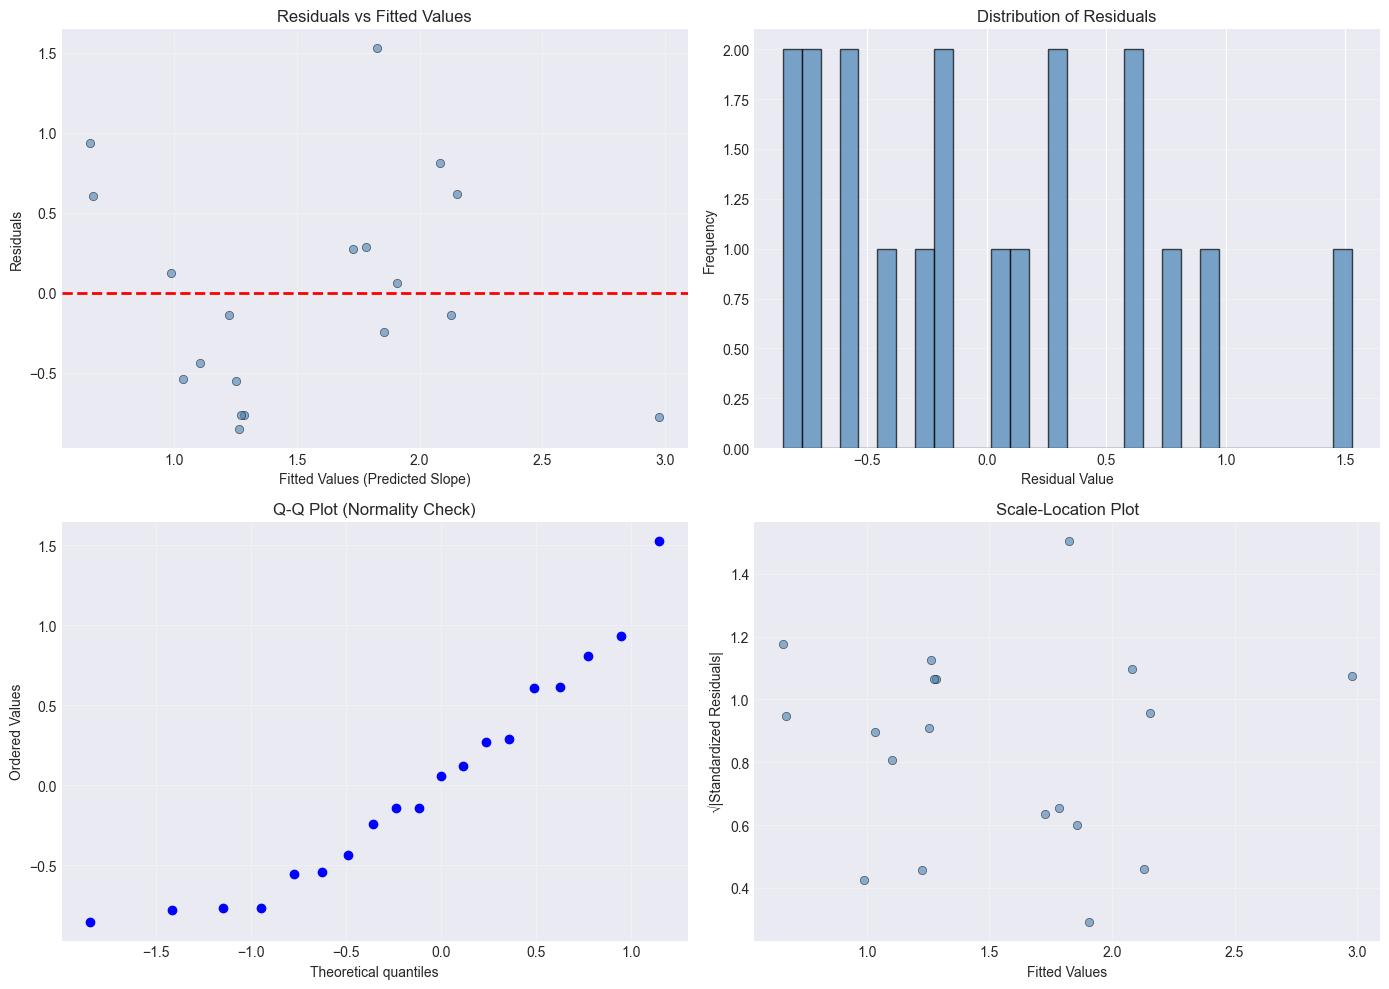

In [20]:
# Residual Diagnostics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Residuals vs Fitted Values
axes[0, 0].scatter(df_comparison['Predicted_Slope'], df_comparison['Residual'], 
                    alpha=0.6, color='steelblue', edgecolors='black', linewidth=0.5)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Fitted Values (Predicted Slope)')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted Values')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Histogram of Residuals
axes[0, 1].hist(df_comparison['Residual'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Residual Value')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Residuals')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Q-Q Plot (Normal Probability Plot)
from scipy import stats
stats.probplot(df_comparison['Residual'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Check)')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Scale-Location Plot (Std. Residuals vs Fitted)
std_residuals = (df_comparison['Residual'] - df_comparison['Residual'].mean()) / df_comparison['Residual'].std()
axes[1, 1].scatter(df_comparison['Predicted_Slope'], np.sqrt(np.abs(std_residuals)), 
                    alpha=0.6, color='steelblue', edgecolors='black', linewidth=0.5)
axes[1, 1].set_xlabel('Fitted Values')
axes[1, 1].set_ylabel('√|Standardized Residuals|')
axes[1, 1].set_title('Scale-Location Plot')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

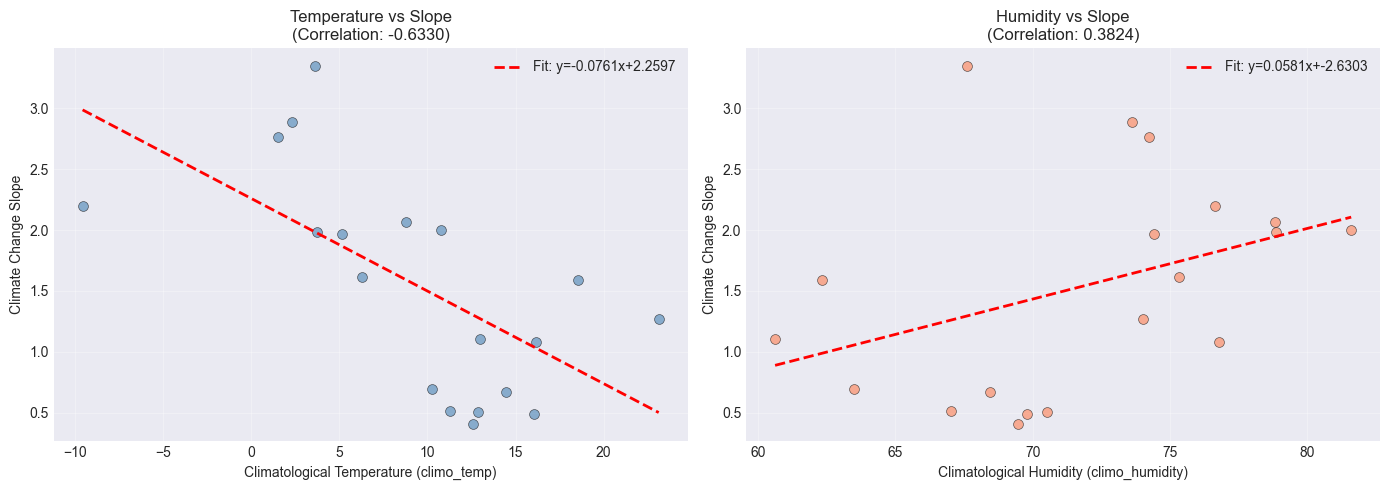

In [21]:
# Feature Relationships with Target Variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get clean data for plotting
plot_data = df_clean.copy()

# Plot 1: climo_temp vs slope
axes[0].scatter(plot_data['climo_temp'], plot_data['slope'], 
                alpha=0.6, color='steelblue', edgecolors='black', linewidth=0.5, s=50)

# Add regression line
z = np.polyfit(plot_data['climo_temp'], plot_data['slope'], 1)
p = np.poly1d(z)
x_line = np.linspace(plot_data['climo_temp'].min(), plot_data['climo_temp'].max(), 100)
axes[0].plot(x_line, p(x_line), "r--", linewidth=2, label=f'Fit: y={z[0]:.4f}x+{z[1]:.4f}')

corr1 = plot_data['climo_temp'].corr(plot_data['slope'])
axes[0].set_xlabel('Climatological Temperature (climo_temp)')
axes[0].set_ylabel('Climate Change Slope')
axes[0].set_title(f'Temperature vs Slope\n(Correlation: {corr1:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: climo_humidity vs slope
axes[1].scatter(plot_data['climo_humidity'], plot_data['slope'], 
                alpha=0.6, color='coral', edgecolors='black', linewidth=0.5, s=50)

# Add regression line
z = np.polyfit(plot_data['climo_humidity'], plot_data['slope'], 1)
p = np.poly1d(z)
x_line = np.linspace(plot_data['climo_humidity'].min(), plot_data['climo_humidity'].max(), 100)
axes[1].plot(x_line, p(x_line), "r--", linewidth=2, label=f'Fit: y={z[0]:.4f}x+{z[1]:.4f}')

corr2 = plot_data['climo_humidity'].corr(plot_data['slope'])
axes[1].set_xlabel('Climatological Humidity (climo_humidity)')
axes[1].set_ylabel('Climate Change Slope')
axes[1].set_title(f'Humidity vs Slope\n(Correlation: {corr2:.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 5: Summary & Key Findings

### Model Performance
Generated summary table of key metrics:

In [22]:
# Create Summary Table
summary_data = {
    'Metric': [
        'Total Observations',
        'Regression R²',
        'Adjusted R²',
        'Model F-Statistic P-Value',
        'Prediction R²',
        'Prediction RMSE',
        'Mean Residual',
        'Std Dev Residual'
    ],
    'Value': [
        f"{model.nobs}",
        f"{r_squared:.4f}",
        f"{adj_r_squared:.4f}",
        f"{f_pvalue:.6f}",
        f"{r2:.4f}",
        f"{rmse:.6f}",
        f"{df_comparison['Residual'].mean():.6f}",
        f"{df_comparison['Residual'].std():.6f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*50)
print("MODEL SUMMARY")
print("="*50)
print(summary_df.to_string(index=False))

# Identify significant predictors
print("\n" + "="*50)
print("SIGNIFICANT PREDICTORS (p < 0.05)")
print("="*50)
sig_predictors = results_df[results_df['P-Value'] < 0.05]
if len(sig_predictors) > 0:
    for _, row in sig_predictors.iterrows():
        print(f"\n{row['Factor']}:")
        print(f"  Coefficient: {row['Coefficient (Slope)']:.6f}")
        print(f"  P-Value: {row['P-Value']:.6f}")
        print(f"  95% CI: [{row['Conf_Int_Low (2.5%)']:.6f}, {row['Conf_Int_High (97.5%)']:.6f}]")
else:
    print("No significant predictors found.")

# Stations with largest residuals (model misfit)
print("\n" + "="*50)
print("STATIONS WITH LARGEST RESIDUALS (TOP 10)")
print("="*50)
top_residuals = df_comparison.nlargest(10, 'Residual')[['StationID', 'StationName', 'Actual_Slope', 'Predicted_Slope', 'Residual']]
print(top_residuals.to_string())


MODEL SUMMARY
                   Metric    Value
       Total Observations     19.0
            Regression R²   0.4305
              Adjusted R²   0.3594
Model F-Statistic P-Value 0.011058
            Prediction R²   0.4305
          Prediction RMSE 0.656094
            Mean Residual 0.000000
         Std Dev Residual 0.674073

SIGNIFICANT PREDICTORS (p < 0.05)

climo_temp:
  Coefficient: -0.068346
  P-Value: 0.012159
  95% CI: [-0.119606, -0.017085]

STATIONS WITH LARGEST RESIDUALS (TOP 10)
      StationID            StationName  Actual_Slope  Predicted_Slope  Residual
15  CA004021520                CHAPLIN      3.350626         1.824302  1.526325
2   ASN00066037     SYDNEY_AIRPORT_AMO      1.590236         0.656340  0.933896
11  USC00201439  CHAMPION_VAN_RIPER_PK      2.891432         2.081702  0.809730
14  RSM00029467                ACHINSK      2.769161         2.153761  0.615400
0   USC00083207              FT_PIERCE      1.272192         0.668136  0.604056
5   GME00004707       

### Results Summary

All results are displayed inline in this notebook:

1. **Regression Results**: Coefficients and statistical tests shown in tables above
2. **Prediction Comparison**: Statistics displayed for actual vs predicted slopes
3. **Visualizations**: All plots displayed inline
   - Regression coefficient summary with confidence intervals
   - Actual vs predicted scatter plot
   - Spatial residual map showing geographic patterns
   - Residual diagnostics (Q-Q plot, histograms, etc.)
   - Feature-target relationship plots